# Nelson-Siegel (NS) con Enfasis Bayesiano

## Modelo

El modelo DNS de Diebold & Li (2006) especifica la curva de rendimientos como:

$$y(\tau) = \beta_0 + \beta_1 \frac{1 - e^{-\lambda\tau}}{\lambda\tau} + \beta_2 \left(\frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right) + \varepsilon$$

Donde:
- $\beta_0$: **Nivel** (long-end, todos los plazos contribuyen igual)
- $\beta_1$: **Pendiente** (diferencia corto vs largo plazo)
- $\beta_2$: **Curvatura** (joroba en plazos medios)
- $\lambda$: parámetro de decaimiento (fijo o estimado)

Como ya sabemos, los valores de $\beta_0, \beta_1$ y $\beta_2$ pueden ser estimado mediante OLS, pero si quisieramos estima $\lambda$ esto requeriria metodologias no lineales. Un enfoque posible para resolver este problema es mediante metodos bayesianos principalemnte nos enfocaremos en es uso de metropolis hasting para la estimacion conjunta de los parametros dado el conjunto de datos

In [1]:
import pymc as pm #libreria especializada en metodologia bayesianas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Datos
Seguiremos trabajando con los datos de rendimientos de tesoros de los EEUU, con los vencimientos de 1, 2, 3, 5, 7, 10, 20, 30 años, y trabajaremos para la estimacion de una unica fecha para analizar como es el proceso de estimar  $\beta_0, \beta_1$, $\beta_2$ y $\lambda$ con metodologia bayesiana con la ayuda de la libreria PyMC

         Date  SVENY01  SVENY02  SVENY03  SVENY05  SVENY07  SVENY10  SVENY20  \
0  1985-11-25   7.8551   8.3626   8.7469   9.2686   9.5924   9.8969  10.4428   
1  1985-12-05   7.8520   8.3516   8.7219   9.2172   9.5270   9.8288  10.3686   
2  1985-12-16   7.5702   7.9670   8.2815   8.7434   9.0647   9.3995   9.9767   
3  1985-12-26   7.6322   7.9513   8.2108   8.6079   8.9005   9.2265   9.8559   
4  1986-01-07   7.6170   7.9314   8.1802   8.5498   8.8175   9.1198   9.7542   

   SVENY30      BETA0     BETA1       BETA2       BETA3      TAU1      TAU2  
0  10.7618  11.581031 -4.400923 -618.930844  619.464293  4.373887  4.360767  
1  10.6358  11.229618 -4.061944 -619.015906  619.379255  3.579314  3.571790  
2  10.2307  10.771218 -3.710152 -619.326990  619.068923  3.533586  3.529975  
3  10.1614  10.836312 -3.603792 -619.654894  618.741501  3.851259  3.846487  
4  10.0924  10.865891 -3.655068 -619.771844  618.624702  3.935893  3.928658  
[ 7.8551  8.3626  8.7469  9.2686  9.5924  9.8969 10

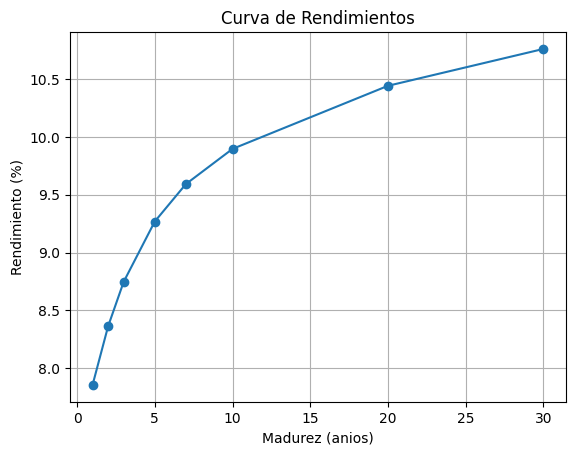

In [14]:
df = pd.read_csv("C:\\Users\\ADMON\\Documents\\Universidad\\Proyecto KMJ\\codigo\\Datos\\muestra_rend_EEUU.csv")
print(df.head())

maturities = [1, 2, 3, 5, 7, 10, 20, 30]

# Convierte a numerico para evitar dtype object en PyMC
yields = pd.to_numeric(df.iloc[0, 1:9], errors="coerce") # solo tomamos la primera fila (rendimientos) y las columnas de 1 a 8 (madurez)
if yields.isna().any():
    raise ValueError("Hay valores no numericos en los rendimientos (NaN despues de convertir).")

yields = yields.to_numpy(dtype=float)
print(yields)

plt.plot(maturities, yields, marker="o")
plt.title("Curva de Rendimientos")
plt.xlabel("Madurez (anios)")
plt.ylabel("Rendimiento (%)")
plt.grid()
plt.show()

In [11]:
# Datos
tau = np.asarray(maturities, dtype=float)
y_obs = np.asarray(yields, dtype=float) / 100.0  # convertir de % a decimal

with pm.Model() as ns_model:

    # ── Priors ────────────────────────────────────────────────────
    # Mismos priors que usamos en MH → comparación directa
    beta0 = pm.Normal("beta0", mu=0.05,  sigma=0.05)
    beta1 = pm.Normal("beta1", mu=-0.01, sigma=0.05)
    beta2 = pm.Flat("beta2")
    beta3 = pm.Flat("beta3") # para extensión a Svensson 

    # Beta(12,14): moda ≈ 0.46, la λ de referencia en de la experiencia del todos lo datos de los rendimientos históricos
    lam1   = pm.Flat("lambda1")
    lam2   = pm.Flat("lambda2") # para extensión a Svensson

    # Error del modelo
    sigma = pm.HalfNormal("sigma", sigma=0.01)

    # ── Curva NS como función determinista ────────────────────────
    lam1_tau = lam1 * tau
    lam2_tau = lam2 * tau
    term1   = (1 - pm.math.exp(-lam1_tau)) / lam1_tau
    term2   = (1- pm.math.exp(-lam1_tau)) / lam1_tau - pm.math.exp(-lam1_tau)
    term3   = (1- pm.math.exp(-lam2_tau)) / lam2_tau - pm.math.exp(-lam2_tau)
    mu      = beta0 + beta1 * term1 + beta2 * term2 + beta3 * term3

    # Likelihood
    y_like = pm.Normal("y_like", mu=mu, sigma=sigma, observed=y_obs)

    # Sampling
    trace = pm.sample(
        draws=3000,
        tune=500,
        target_accept=0.98,
        return_inferencedata=True,
        nuts_sampler="numpyro"
    )

# 0 32 7 0 divergece 0.95

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

There were 562 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


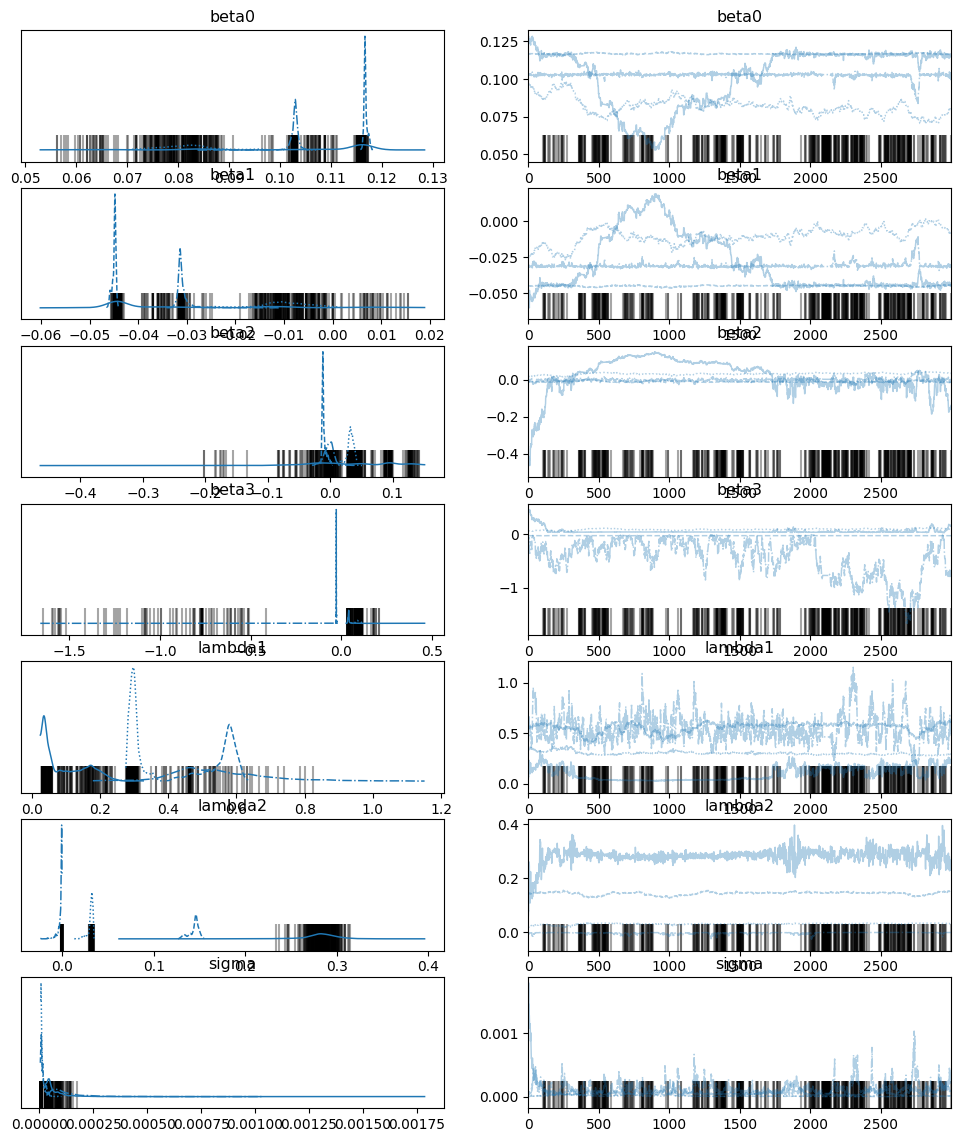

In [12]:
pm.plot_trace(trace, var_names=["beta0", "beta1", "beta2","beta3", "lambda1", "lambda2", "sigma"])
plt.show()

In [13]:
summary = pm.summary(
    trace,
    var_names=["beta0", "beta1", "beta2","beta3", "lambda1", "lambda2", "sigma"],
    hdi_prob=0.95
)

print(summary)

print("\nChequeo rapido de convergencia:")
print("r_hat max:", summary["r_hat"].max())
print("ess_bulk min:", summary["ess_bulk"].min())
print("ess_tail min:", summary["ess_tail"].min())

          mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta0    0.101  0.016     0.072      0.118      0.007    0.002       6.0   
beta1   -0.029  0.016    -0.046     -0.001      0.007    0.002       6.0   
beta2    0.010  0.048    -0.040      0.135      0.011    0.021       9.0   
beta3   -0.080  0.276    -0.821      0.124      0.115    0.120       5.0   
lambda1  0.376  0.207     0.026      0.646      0.095    0.034       5.0   
lambda2  0.113  0.112    -0.008      0.300      0.055    0.023       5.0   
sigma    0.000  0.000     0.000      0.000      0.000    0.000       6.0   

         ess_tail  r_hat  
beta0        43.0   1.89  
beta1        42.0   1.88  
beta2        16.0   1.75  
beta3        14.0   2.52  
lambda1      15.0   2.18  
lambda2      21.0   3.01  
sigma        53.0   1.87  

Chequeo rapido de convergencia:
r_hat max: 3.01
ess_bulk min: 5.0
ess_tail min: 14.0


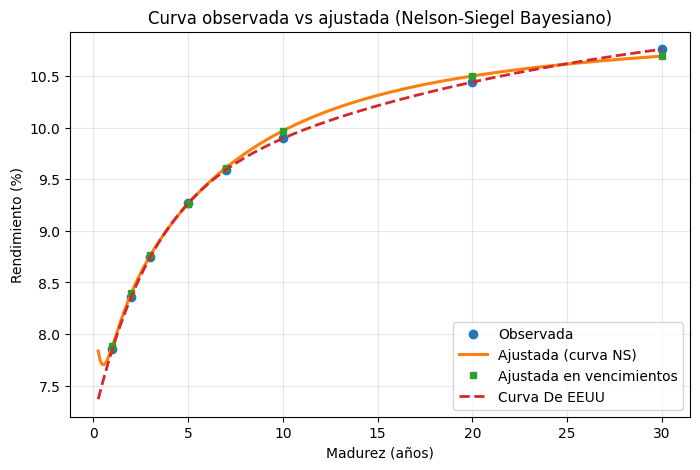

Parametros medios posteriores (escala decimal):
beta0=0.1108, beta1=-0.0264, beta2=-0.0164, beta3=-0.0286, lambda1=0.403739, lambda2=2.944443


In [9]:
# Medias posteriores de parametros
beta0_hat = float(trace.posterior["beta0"].mean().values)
beta1_hat = float(trace.posterior["beta1"].mean().values)
beta2_hat = float(trace.posterior["beta2"].mean().values)
beta3_hat = float(trace.posterior["beta3"].mean().values)
lambda1_hat = float(trace.posterior["lambda1"].mean().values)
lambda2_hat = float(trace.posterior["lambda2"].mean().values)

# Curva ajustada Nelson-Siegel en vencimientos observados (escala decimal)
term1_hat = (1 - np.exp(-lambda1_hat * tau)) / (lambda1_hat * tau)
term2_hat = term1_hat - np.exp(-lambda1_hat * tau)
term3_hat = (1 - np.exp(-lambda2_hat * tau)) / (lambda2_hat * tau) - np.exp(-lambda2_hat * tau)
y_fit = beta0_hat + beta1_hat * term1_hat + beta2_hat * term2_hat + beta3_hat * term3_hat

# Curva ajustada suave en una malla continua de vencimientos
# Nota: se evita tau=0 para no dividir entre cero
tau_grid = np.linspace(0.25, 30, 300)
term1_grid = (1 - np.exp(-lambda1_hat * tau_grid)) / (lambda1_hat * tau_grid)
term2_grid = term1_grid - np.exp(-lambda1_hat * tau_grid)
term3_grid = (1 - np.exp(-lambda2_hat * tau_grid)) / (lambda2_hat * tau_grid) - np.exp(-lambda2_hat * tau_grid)
y_fit_grid = beta0_hat + beta1_hat * term1_grid + beta2_hat * term2_grid + beta3_hat * term3_grid

# Curva adicional con parametros del comentario final (en %)
beta0_c = df["BETA0"].iloc[0]  # -4.40092278524114
beta1_c = df["BETA1"].iloc[0]  # -618.930843769627
beta2_c = df["BETA2"].iloc[0]  # 619.464293142355
beta3_c = df["BETA3"].iloc[0]  # 4.37388682468365
lambda1_c = df["TAU1"].iloc[0] # 4.36076744378776
lambda2_c = df["TAU2"].iloc[0] #

term1_c = (1 - np.exp(-tau_grid / lambda1_c )) / (tau_grid / lambda1_c)
term2_c = term1_c - np.exp(-tau_grid / lambda1_c)
term3_c = (1 - np.exp(-tau_grid / lambda2_c)) / (tau_grid / lambda2_c) - np.exp(-tau_grid / lambda2_c)
y_fit_comment_pct = beta0_c + beta1_c * term1_c + beta2_c * term2_c + beta3_c * term3_c

# Convertir a porcentaje para graficar
y_obs_pct = y_obs * 100
y_fit_pct = y_fit * 100
y_fit_grid_pct = y_fit_grid * 100

plt.figure(figsize=(8, 5))
plt.plot(tau, y_obs_pct, "o", ms=6, label="Observada")
plt.plot(tau_grid, y_fit_grid_pct, "-", lw=2.2, label="Ajustada (curva NS)")
plt.plot(tau, y_fit_pct, "s", ms=5, label="Ajustada en vencimientos")
plt.plot(tau_grid, y_fit_comment_pct, "--", lw=2.0, label="Curva De EEUU")
plt.title("Curva observada vs ajustada (Nelson-Siegel Bayesiano)")
plt.xlabel("Madurez (años)")
plt.ylabel("Rendimiento (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Parametros medios posteriores (escala decimal):")
print(f"beta0={beta0_hat:.4f}, beta1={beta1_hat:.4f}, beta2={beta2_hat:.4f}, beta3={beta3_hat:.4f}, lambda1={lambda1_hat:.6f}, lambda2={lambda2_hat:.6f}")



In [10]:
# Diagnostico compacto de la corrida actual
divergences = int(trace.sample_stats["diverging"].sum().values)
n_draws = int(np.prod(trace.sample_stats["diverging"].shape))

summary_chk = pm.summary(
    trace,
    var_names=["beta0", "beta1", "beta2","beta3", "lambda1", "lambda2", "sigma"],
    hdi_prob=0.95
)

print(f"Divergencias: {divergences} de {n_draws} draws")
print("r_hat max:", float(summary_chk["r_hat"].max()))
print("ess_bulk min:", float(summary_chk["ess_bulk"].min()))
print("ess_tail min:", float(summary_chk["ess_tail"].min()))

Divergencias: 0 de 12000 draws
r_hat max: 1.0
ess_bulk min: 1983.0
ess_tail min: 2845.0
